In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas numpy scikit-learn matplotlib -q

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/MSIL_Dataset/"
SAVE_DIR    = "/content/drive/MyDrive/MSIL_Dataset/parameters_nslkdd/"

# Test files — add more if needed
TEST_FILES = [
    "KDDTest+.csv",
]

# Attack categories for per-category breakdown (Cell 7)
# NSL-KDD attack families
DOS_ATTACKS   = {"neptune","smurf","pod","teardrop","back","land",
                 "apache2","udpstorm","processtable","worm"}
PROBE_ATTACKS = {"ipsweep","nmap","portsweep","satan","mscan","saint"}
R2L_ATTACKS   = {"ftp_write","guess_passwd","imap","multihop","phf",
                 "spy","warezclient","warezmaster","sendmail","named",
                 "snmpgetattack","snmpguess","xlock","xsnoop","httptunnel"}
U2R_ATTACKS   = {"buffer_overflow","loadmodule","perl","rootkit",
                 "ps","sqlattack","xterm"}

In [ ]:
with open(os.path.join(SAVE_DIR, "scaler.pkl"), "rb") as f:
    scaler = pickle.load(f)

with open(os.path.join(SAVE_DIR, "pca.pkl"), "rb") as f:
    pca = pickle.load(f)

threshold  = float(np.loadtxt(os.path.join(SAVE_DIR, "threshold.txt")))
clip_value = float(np.loadtxt(os.path.join(SAVE_DIR, "clip_value.txt")))

# Load feature list saved by Phase 1 (guarantees Phase 1/2 use identical features)
with open(os.path.join(SAVE_DIR, "features.txt")) as f:
    FEATURES = [line.strip() for line in f if line.strip()]

print("✅ Model loaded successfully!")
print(f"   Features    : {FEATURES}")
print(f"   Scaler mean : shape={scaler.mean_.shape}")
print(f"   PCA         : {pca.n_components_} components")
print(f"   Threshold   : {threshold:.4f}")
print(f"   Clip value  : ±{clip_value}")

assert scaler.mean_.shape[0] == len(FEATURES), (
    f"Feature count mismatch: scaler has {scaler.mean_.shape[0]} features "
    f"but features.txt has {len(FEATURES)}. Re-run Phase 1."
)


✅ Model loaded successfully!
   Features    : ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_serror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_diff_srv_rate']
   Scaler mean : shape=(12,)
   PCA         : 4 components
   Threshold   : 3.2230
   Clip value  : ±5.0


In [ ]:
def parse_label(raw_label):
    """
    Returns "BENIGN" or "ATTACK". Handles whitespace and case robustly.
    Strips trailing dots, spaces, newlines before comparing.
    """
    cleaned = str(raw_label).strip().lower().rstrip(".")
    return "BENIGN" if cleaned == "normal" else "ATTACK"

def get_attack_family(raw_label):
    """Returns DoS / Probe / R2L / U2R / Normal / Unknown for breakdown table."""
    cleaned = str(raw_label).strip().lower().rstrip(".")
    if cleaned == "normal":
        return "Normal"
    if cleaned in DOS_ATTACKS:
        return "DoS"
    if cleaned in PROBE_ATTACKS:
        return "Probe"
    if cleaned in R2L_ATTACKS:
        return "R2L"
    if cleaned in U2R_ATTACKS:
        return "U2R"
    return "Unknown"

In [ ]:
def evaluate_file(filepath):
    """
    Load CSV, scale + clip, run PCA, compute reconstruction error,
    flag anomalies, return full metrics dict.
    """
    fname = os.path.basename(filepath)
    print(f"\n{'='*60}")
    print(f"📂 Evaluating: {fname}")

    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    assert "label" in df.columns, (
        f"'label' column not found in {fname}. "
        f"Columns: {df.columns.tolist()}"
    )

    df["parsed_label"]  = df["label"].apply(parse_label)
    df["attack_family"] = df["label"].apply(get_attack_family)

    # Confirm label parsing worked
    lc = df["parsed_label"].value_counts()
    print(f"   Label check → BENIGN: {lc.get('BENIGN',0)}  ATTACK: {lc.get('ATTACK',0)}")
    if lc.get("BENIGN", 0) == 0:
        print("   ⚠️  WARNING: No BENIGN samples found — check label column values:")
        print("  ", df["label"].unique()[:10])

    # Extract features
    missing = [f for f in FEATURES if f not in df.columns]
    if missing:
        raise ValueError(f"Missing features: {missing}")

    X_raw  = df[FEATURES].values.astype(np.float64)
    labels = df["parsed_label"].values
    family = df["attack_family"].values

    # Clean
    bad         = np.isnan(X_raw).any(axis=1) | np.isinf(X_raw).any(axis=1)
    X_c         = X_raw[~bad]
    labels_c    = labels[~bad]
    family_c    = family[~bad]

    if bad.sum() > 0:
        print(f"   ⚠️  {bad.sum()} rows removed (NaN/inf)")

    # Scale + clip  — MUST match Phase 1 exactly
    X_sc  = np.clip(scaler.transform(X_c), -clip_value, clip_value)

    # PCA reconstruct
    Y     = pca.transform(X_sc)
    X_hat = pca.inverse_transform(Y)
    errors = np.sum((X_sc - X_hat) ** 2, axis=1)

    # Binary prediction
    y_pred        = (errors > threshold).astype(int)
    y_true_binary = (labels_c != "BENIGN").astype(int)

    cm = confusion_matrix(y_true_binary, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    dr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    print(f"   Total samples: {len(labels_c)}  |  Benign: {(labels_c=='BENIGN').sum()}  |  Attack: {(labels_c!='BENIGN').sum()}")
    print(f"   DR={dr:.4f}  FAR={far:.4f}  TP={tp}  FP={fp}  TN={tn}  FN={fn}")

    # Error stats
    b_err = errors[labels_c == "BENIGN"]
    a_err = errors[labels_c != "BENIGN"]
    print(f"   BENIGN errors  → mean={b_err.mean():.3f}  max={b_err.max():.3f}" if len(b_err) else "")
    print(f"   ATTACK errors  → mean={a_err.mean():.3f}  max={a_err.max():.3f}" if len(a_err) else "")
    if len(b_err) > 0 and len(a_err) > 0 and b_err.mean() > 0:
        sep = a_err.mean() / b_err.mean()
        qual = "✅ good" if sep > 2 else "⚠️  poor"
        print(f"   Separation: attack_mean / benign_mean = {sep:.2f}x  ({qual})")

    return {
        "fname"    : fname,
        "n_total"  : len(labels_c),
        "n_benign" : int((labels_c == "BENIGN").sum()),
        "n_attack" : int((labels_c != "BENIGN").sum()),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "DR": dr, "FAR": far,
        "errors"   : errors,
        "labels"   : labels_c,
        "family"   : family_c,
    }

In [ ]:
results = {}

for fname in TEST_FILES:
    fpath = os.path.join(DATASET_DIR, fname)
    if not os.path.exists(fpath):
        print(f"⚠️  Not found, skipping: {fname}")
        continue
    try:
        results[fname] = evaluate_file(fpath)
    except Exception as e:
        print(f"❌ Error on {fname}: {e}")
        import traceback; traceback.print_exc()

# Summary table
print(f"\n{'='*95}")
print(f"📊 VALIDATION SUMMARY  (threshold={threshold:.4f}  clip=±{clip_value}  components={pca.n_components_})")
print(f"{'='*95}")
print(f"{'File':<40} {'DR':>7} {'FAR':>7} {'TP':>7} {'FP':>7} {'TN':>7} {'FN':>7} {'Atk':>6} {'Ben':>6}")
print(f"{'-'*95}")
for fname, r in results.items():
    short = fname[:37] + "..." if len(fname) > 40 else fname
    print(f"{short:<40} {r['DR']:>7.4f} {r['FAR']:>7.4f} "
          f"{r['TP']:>7} {r['FP']:>7} {r['TN']:>7} {r['FN']:>7} "
          f"{r['n_attack']:>6} {r['n_benign']:>6}")
print(f"{'='*95}")


📂 Evaluating: KDDTest+.csv
   Label check → BENIGN: 9711  ATTACK: 12833
   Total samples: 22544  |  Benign: 9711  |  Attack: 12833
   DR=0.5752  FAR=0.0430  TP=7382  FP=418  TN=9293  FN=5451
   BENIGN errors  → mean=0.793  max=73.004
   ATTACK errors  → mean=17.901  max=78.572
   Separation: attack_mean / benign_mean = 22.58x  (✅ good)

📊 VALIDATION SUMMARY  (threshold=3.2230  clip=±5.0  components=4)
File                                          DR     FAR      TP      FP      TN      FN    Atk    Ben
-----------------------------------------------------------------------------------------------
KDDTest+.csv                              0.5752  0.0430    7382     418    9293    5451  12833   9711


In [ ]:
for fname, r in results.items():
    print(f"\n📊 Per-Family Breakdown — {fname}")
    print(f"{'Family':<12} {'Total':>8} {'Detected':>10} {'DR':>8}")
    print(f"{'-'*42}")

    errors  = r["errors"]
    labels  = r["labels"]
    family  = r["family"]

    for fam in ["DoS", "Probe", "R2L", "U2R", "Normal"]:
        mask  = (family == fam)
        total = mask.sum()
        if total == 0:
            continue
        if fam == "Normal":
            # For normal: "detected" means falsely flagged (FP)
            flagged = (errors[mask] > threshold).sum()
            print(f"{'Normal (benign)':<12} {total:>8} {flagged:>10} {'(FAR=' + f'{flagged/total:.3f})':>8}")
        else:
            detected = (errors[mask] > threshold).sum()
            dr_fam   = detected / total if total > 0 else 0.0
            print(f"{fam:<12} {total:>8} {detected:>10} {dr_fam:>8.4f}")


📊 Per-Family Breakdown — KDDTest+.csv
Family          Total   Detected       DR
------------------------------------------
DoS              7167       5644   0.7875
Probe            2421       1386   0.5725
R2L              2885        309   0.1071
U2R                67         24   0.3582
Normal (benign)     9711        418 (FAR=0.043)


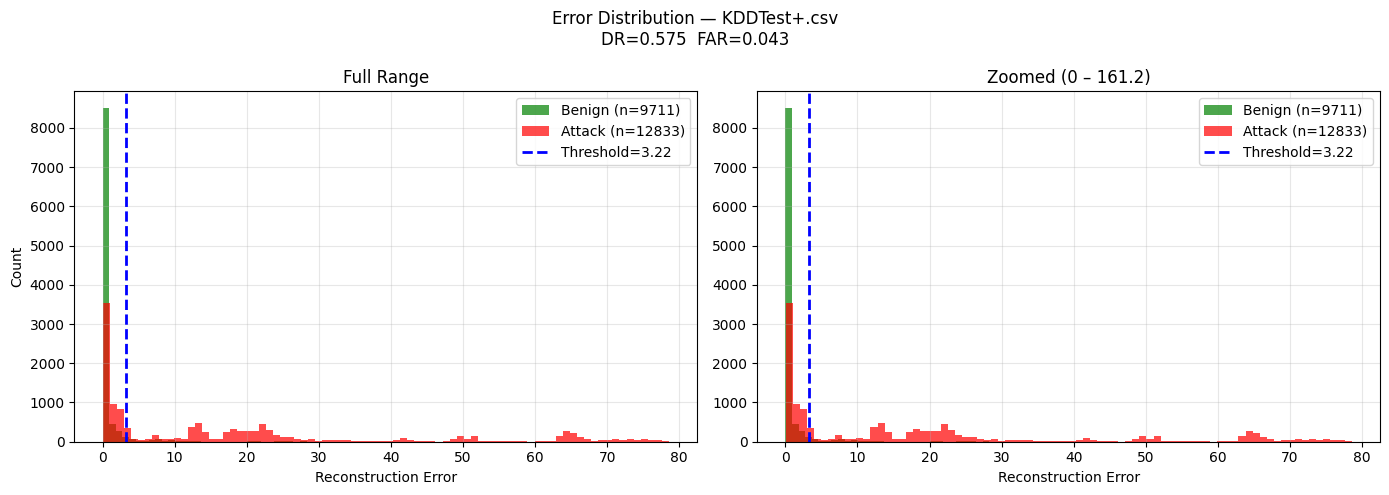

In [ ]:
for fname, r in results.items():
    errors = r["errors"]
    labels = r["labels"]

    b_err  = errors[labels == "BENIGN"]
    a_err  = errors[labels != "BENIGN"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: full range
    ax = axes[0]
    if len(b_err): ax.hist(b_err, bins=80, alpha=0.7, color="green",
                            label=f"Benign (n={len(b_err)})")
    if len(a_err): ax.hist(a_err, bins=80, alpha=0.7, color="red",
                            label=f"Attack (n={len(a_err)})")
    ax.axvline(threshold, color="blue", linewidth=2, linestyle="--",
               label=f"Threshold={threshold:.2f}")
    ax.set_xlabel("Reconstruction Error")
    ax.set_ylabel("Count")
    ax.set_title("Full Range")
    ax.legend(); ax.grid(alpha=0.3)

    # Right: zoomed to 0–50x threshold to see the overlap clearly
    ax2 = axes[1]
    zoom = threshold * 50
    b_zoom = b_err[b_err <= zoom]
    a_zoom = a_err[a_err <= zoom]
    if len(b_zoom): ax2.hist(b_zoom, bins=80, alpha=0.7, color="green",
                              label=f"Benign (n={len(b_zoom)})")
    if len(a_zoom): ax2.hist(a_zoom, bins=80, alpha=0.7, color="red",
                              label=f"Attack (n={len(a_zoom)})")
    ax2.axvline(threshold, color="blue", linewidth=2, linestyle="--",
                label=f"Threshold={threshold:.2f}")
    ax2.set_xlabel("Reconstruction Error")
    ax2.set_title(f"Zoomed (0 – {zoom:.1f})")
    ax2.legend(); ax2.grid(alpha=0.3)

    fig.suptitle(f"Error Distribution — {fname}\nDR={r['DR']:.3f}  FAR={r['FAR']:.3f}",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


In [ ]:
print(f"\n📊 THRESHOLD SWEEP")
print(f"{'Threshold':>12}  {'Mult':>6}", end="")
for fname in list(results.keys()):
    short = os.path.basename(fname)[:18]
    print(f"  {short:<18} DR /  FAR", end="")
print()
print("-" * (30 + 32 * len(results)))

for mult in [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0]:
    t = threshold * mult
    print(f"  {t:>10.4f}  {mult:>5.2f}x", end="")
    for fname, r in results.items():
        errors        = r["errors"]
        labels        = r["labels"]
        y_pred        = (errors > t).astype(int)
        y_true_binary = (labels != "BENIGN").astype(int)
        cm_t          = confusion_matrix(y_true_binary, y_pred, labels=[0, 1])
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        dr_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
        far_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0.0
        print(f"  {dr_t:>6.3f} / {far_t:>5.3f}         ", end="")
    marker = " ← trained threshold" if mult == 1.0 else ""
    print(marker)

print(f"\n💡 To apply a different threshold permanently:")
print(f"   Edit threshold.txt in SAVE_DIR and re-run from Cell 6.")
print(f"   No re-training needed.")


📊 THRESHOLD SWEEP
   Threshold    Mult  KDDTest+.csv       DR /  FAR
--------------------------------------------------------------
      0.3223   0.10x   0.834 / 0.225         
      0.8058   0.25x   0.752 / 0.135         
      1.6115   0.50x   0.677 / 0.088         
      2.4173   0.75x   0.614 / 0.059         
      3.2230   1.00x   0.575 / 0.043          ← trained threshold
      4.8345   1.50x   0.554 / 0.033         
      6.4460   2.00x   0.548 / 0.030         
      9.6690   3.00x   0.520 / 0.016         
     16.1150   5.00x   0.413 / 0.008         
     32.2301  10.00x   0.184 / 0.001         

💡 To apply a different threshold permanently:
   Edit threshold.txt in SAVE_DIR and re-run from Cell 6.
   No re-training needed.
